# Reconciliation-Fault Model: Point-Estimate vs. Full-Distribution (cleaned up)

This notebook finishes the three loose threads left in `Untitled.ipynb`:

1. **The chi-square rejection** (`full_reconciliation_prediction`, point-estimate K) was never
   re-tested after anything changed — it's the one number you've been carrying around.
2. **The full-distribution model** (Theorem 1/2 propagation) was built, sanity-checked against
   itself at one hardcoded (N=3000, QBER=0.03) example, and then never touched real data.
3. **The single-fault filter** (only comparing against runs where exactly 1 fault fired,
   matching the model's assumption) was applied — but only using `mismatch_from_pass[0]`,
   which implicitly assumes every single fault landed in *pass 1*. That's not obviously
   true: later Cascade passes have far more corrections happening (`C_i` grows with `i`), so
   most single-fault runs probably had their one fault in pass 2, 3, or 4, not pass 1.

This notebook fixes #3 properly (marginalize over which pass the fault landed in, weighted
by each model's own predicted correction counts per pass) and runs a real chi-square test
for **both** the point-estimate and full-distribution models on the same, correctly-filtered
data — so you get one clean side-by-side answer instead of three unfinished threads.


In [1]:
import sys, json, ast, math
from pathlib import Path
from math import comb, ceil, lgamma, log
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2, hypergeom

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

RECON_CSV = PROJECT_DIR / "results" / "sdc_realchannel_reconciliation_allkeys_asymptotic_fixed.csv"
KEY_PAIRS_CSV = PROJECT_DIR / "results" / "key_pairs_metadata.csv"

recon_df = pd.read_csv(RECON_CSV)
key_pairs_df = pd.read_csv(KEY_PAIRS_CSV)
print(f"Loaded {len(recon_df)} reconciliation rows, {len(key_pairs_df)} key pairs")
print(recon_df.columns.tolist())


Loaded 400 reconciliation rows, 5 key pairs
['toeplitz_prob', 'final_key_prob', 'reconciliation_prob', 'verify_digest_prob', 'seed', 'output_path', 'k_pe', 'total_corrections', 'secure_key_length', 't_verify', 'digest_length', 'verification_passed', 'remaining_errors_after_reconciliation', 'non_convergent', 'error', 'elapsed_seconds', 'faults_fired', 'length_mode', 'keys_match', 'alice_error', 'alice_output_path', 'run', 'bob_output_path', 'fault_type', 'prob', 'key_index', 'qber']


## Clean the data

Same baseline-contamination check as before (faults recorded as firing at prob=0 in a small
fraction of rows) — reapplied here so this notebook doesn't silently inherit a bug you
already found and fixed elsewhere. Adjust the column names below if your CSV differs.

In [2]:
def is_baseline_contaminated(row):
    fired = row.get("faults_fired")
    fired_empty = (fired == "{}" or fired == {} or (isinstance(fired, str) and fired.strip() == "{}"))
    return (row.get("reconciliation_prob", 0) == 0) and not fired_empty

recon_df["faults_fired_dict"] = recon_df["faults_fired"].apply(
    lambda d: ast.literal_eval(d) if isinstance(d, str) else (d or {})
)
recon_df["n_faults_fired"] = recon_df["faults_fired_dict"].apply(
    lambda d: d.get("reconciliation_state", 0)
)

contaminated = recon_df.apply(is_baseline_contaminated, axis=1)
print(f"Contaminated rows: {contaminated.sum()}/{len(recon_df)}")
recon_df_clean = recon_df[~contaminated].copy()

single_fault_df = recon_df_clean[recon_df_clean["n_faults_fired"] == 1].copy()
print(f"Rows with exactly 1 fault fired (post-cleaning): {len(single_fault_df)}")
if len(single_fault_df) < 10:
    print("WARNING: very few single-fault rows -- chi-square result below will be noisy. "
          "Consider pooling across keys/probabilities rather than testing per-key.")


Contaminated rows: 0/400
Rows with exactly 1 fault fired (post-cleaning): 53


## Shared Cascade-schedule helpers

In [3]:
def m_block(iteration_nr, qber, M=4):
    if iteration_nr == 1:
        return ceil(0.73 / qber)
    return 2 * m_block(iteration_nr - 1, qber, M)

def block_schedule(qber, M=4):
    return [m_block(i, qber, M) for i in range(1, M + 1)]


## Model A: point estimate (the original, rejected model)

Tracks a single scalar `K` (expected number of remaining background errors), updated by its
expected value each pass. This is what `reconciliation_fault_model.py` and the earlier
rejected chi-square test both used.

In [4]:
def P_survive_point_estimate(K, N, m):
    K = int(round(K))
    pop, sample = N - 1, m - 1
    denom = comb(pop, sample)
    s = 0
    for i in range(0, sample + 1, 2):  # even i survives (fault's own error stays isolated)
        if i <= K and (sample - i) <= (pop - K):
            s += comb(K, i) * comb(pop - K, sample - i)
    return s / denom

def P_odd_point(K, N, m):
    K = int(round(K))
    denom = comb(N, m)
    s = 0
    for i in range(1, m + 1, 2):
        if i <= K and (m - i) <= (N - K):
            s += comb(K, i) * comb(N - K, m - i)
    return s / denom

def point_estimate_model(n_bits, qber, M=4):
    """Returns per-pass: expected corrections C_i, survival-if-faulted-here P_survive_i,
    and the resulting P(permanent mismatch | single fault injected at pass i)."""
    m_sizes = block_schedule(qber, M)
    K = n_bits * qber
    C_trace, survive = [], []
    for m in m_sizes:
        n_blocks = n_bits / m
        p_odd = P_odd_point(K, n_bits, m)
        C_i = n_blocks * p_odd
        C_trace.append(C_i)
        p_surv = P_survive_point_estimate(K, n_bits, m)
        survive.append(p_surv)
        K = max(0, K - C_i)
    mismatch_from_pass = [float(np.prod(survive[i:])) for i in range(M)]
    return {"m_sizes": m_sizes, "C_trace": C_trace, "survive": survive,
            "mismatch_from_pass": mismatch_from_pass}


## Model B: full distribution

Same idea, but propagates the *full* probability distribution over the background-error
count through each pass (Theorem 1/2 recursion), instead of collapsing it to one scalar. This
existed in `Untitled.ipynb` only as a standalone sanity check at one hardcoded (N, QBER) —
generalized here to run on any key pair, so it can actually be tested against real data.

In [5]:
def log_comb(n, k):
    if k < 0 or k > n:
        return float('-inf')
    return lgamma(n + 1) - lgamma(k + 1) - lgamma(n - k + 1)

def _log_binom_vec(k):
    """log(comb(k,i)) for i=0..k, via lgamma -- never overflows, unlike
    building comb(k,i) directly (which does, once k gets into the hundreds+
    for low-QBER keys with large Cascade block sizes)."""
    return np.array([log_comb(k, i) for i in range(k + 1)])

def _rescaled_binom_split(k):
    """f_even, f_odd as (coeffs, log_scale) pairs where true_value =
    coeffs * exp(log_scale). Rescaling by the max keeps `coeffs` near [0,1]
    regardless of how large k is."""
    logvals = _log_binom_vec(k)
    max_log = logvals.max()
    coeffs = np.exp(logvals - max_log)
    f_even = coeffs.copy(); f_even[1::2] = 0.0   # zero out odd positions
    f_odd = coeffs.copy();  f_odd[0::2] = 0.0    # zero out even positions
    return (f_even, max_log), (f_odd, max_log)

def _scaled_convolve(a, b):
    """Convolve two (coeffs, log_scale) pairs, renormalizing so the mantissa
    stays near [0,1] -- keeps np.convolve (fast, vectorized) usable without
    ever forming an unrepresentable intermediate value."""
    (ca, la), (cb, lb) = a, b
    conv = np.convolve(ca, cb)
    m = conv.max()
    if m <= 0 or not np.isfinite(m):
        return conv, la + lb
    return conv / m, la + lb + np.log(m)

def _poly_pow_scaled(pair, power):
    if power == 0:
        return (np.array([1.0]), 0.0)
    result = pair
    for _ in range(power - 1):
        result = _scaled_convolve(result, pair)
    return result

def C_ijy(k, num_blocks, j, y, n):
    """Numerically stable -- same math as the original comb()-based version,
    verified to match it exactly at small scale where the original doesn't
    overflow. Returns 0.0 (not a crash) for tail probabilities too small for
    float64 to represent relative to the distribution's peak."""
    (f_even, s_even), (f_odd, s_odd) = _rescaled_binom_split(k)
    odd_pow, even_pow = j - y, num_blocks - (j - y)
    if odd_pow < 0 or even_pow < 0:
        return 0.0
    poly1, scale1 = _poly_pow_scaled((f_odd, s_odd), odd_pow) if odd_pow > 0 else (np.array([1.0]), 0.0)
    poly2, scale2 = _poly_pow_scaled((f_even, s_even), even_pow) if even_pow > 0 else (np.array([1.0]), 0.0)
    full, total_scale = _scaled_convolve((poly1, scale1), (poly2, scale2))
    if j >= len(full) or full[j] <= 0:
        return 0.0
    log_result = np.log(full[j]) + total_scale
    return float(np.exp(log_result)) if log_result > -700 else 0.0

def delta(k, num_blocks, j, y, n):
    """Also kept in log-space until the final exponentiation, for the same
    reason -- comb(n, j) can get large too when n (full key length) is in
    the thousands, even though j itself stays small."""
    if j - y < 0 or j - y > num_blocks:
        return 0.0
    c_val = C_ijy(k, num_blocks, j, y, n)
    if c_val <= 0:
        return 0.0
    log_result = log_comb(num_blocks, j - y) - log_comb(n, j) + np.log(c_val)
    return float(np.exp(log_result)) if log_result > -700 else 0.0

def initial_distribution(n, qber, n_std=8):
    mean = n * qber
    std = (n * qber * (1 - qber)) ** 0.5
    lo, hi = max(0, int(mean - n_std * std)), min(n, int(mean + n_std * std))
    dist = {}
    for l in range(lo, hi + 1):
        logp = log_comb(n, l) + l * log(qber) + (n - l) * log(1 - qber)
        dist[l] = np.exp(logp)
    total = sum(dist.values())
    return {k: v / total for k, v in dist.items()}

def prob_odd_count_hypergeom(N, K, m):
    if K <= 0 or m <= 0:
        return 0.0
    return sum(hypergeom.pmf(i, N, K, m) for i in range(1, min(K, m) + 1, 2))

def prob_even_count_hypergeom_excl(N, K, m):
    if m <= 0:
        return 1.0
    return sum(hypergeom.pmf(i, N - 1, K, m - 1) for i in range(0, min(K, m) + 1, 2))

def apply_theorem1(P_prev, k, n, max_y=None):
    num_blocks = n // k
    if max_y is None:
        max_y = max(P_prev.keys())

    P_next = {}
    for y in range(max_y + 1):
        s = 0.0
        for j in range(y, min(y + num_blocks, max_y) + 1):
            if j in P_prev and P_prev[j] > 1e-14:
                s += P_prev[j] * delta(k, num_blocks, j, y, n)
        if s > 1e-14:
            P_next[y] = s
    return P_next

def P_survive_distributional(P_dist, N, m):
    pop, sample = N - 1, m - 1
    denom = comb(pop, sample)
    total = 0.0
    for y, p_y in P_dist.items():
        y = int(round(y))
        s = 0
        for i in range(0, sample + 1, 2):
            if i <= y and (sample - i) <= (pop - y):
                s += comb(y, i) * comb(pop - y, sample - i)
        total += p_y * (s / denom)
    return total

def expected_corrections_distributional(P_dist, N, m):
    n_blocks = N / m
    return n_blocks * sum(p_y * prob_odd_count_hypergeom(N, int(round(y)), m)
                            for y, p_y in P_dist.items())

def distributional_model(n_bits, qber, M=4):
    # Clamp block size to the key length -- a real Cascade pass never uses a
    # block bigger than the whole key. Without this, a low-QBER key can push
    # m4 = 8*m1 past n_bits, making num_blocks = n//k == 0, which silently
    # discards nearly all probability mass each pass until apply_theorem1
    # returns an empty dict.
    m_sizes = [min(m, n_bits) for m in block_schedule(qber, M)]
    P0 = initial_distribution(n_bits, qber)
    dists, C_trace, survive = [P0], [], []
    for m in m_sizes:
        if not dists[-1]:
            # Already lost all mass on an earlier pass (shouldn't happen post-clamp,
            # but fail loudly instead of crashing on max() of an empty dict if it does).
            print(f"WARNING: distribution went to zero mass before pass with m={m} "
                  f"(n_bits={n_bits}, qber={qber}) -- check this key's block schedule.")
            C_trace.append(0.0)
            survive.append(1.0)
            dists.append({})
            continue
        C_i = expected_corrections_distributional(dists[-1], n_bits, m)
        C_trace.append(C_i)
        survive.append(P_survive_distributional(dists[-1], n_bits, m))
        dists.append(apply_theorem1(dists[-1], m, n_bits))
    mismatch_from_pass = [float(np.prod(survive[i:])) for i in range(M)]
    return {"m_sizes": m_sizes, "C_trace": C_trace, "survive": survive,
            "mismatch_from_pass": mismatch_from_pass}


## The actual fix: marginalize over which pass the single fault landed in

Both models above give `mismatch_from_pass[i]`: the probability of a permanent mismatch
**given the fault landed in pass i specifically**. A "single fault fired" run doesn't tell you
which pass it was in. Weight by each model's own predicted `C_i` (expected corrections at
that pass) — passes with more corrections happening are proportionally more likely to be
where the one fault landed.

In [6]:
def marginal_prediction(model_result):
    C_trace = np.array(model_result["C_trace"])
    weights = C_trace / C_trace.sum()
    mismatch_from_pass = np.array(model_result["mismatch_from_pass"])
    return float(np.dot(weights, mismatch_from_pass)), weights.tolist()


## Chi-square goodness-of-fit, both models, same (cleaned, single-fault-filtered) data

In [7]:
def chi_square_test(single_fault_df, key_pairs_df, model_fn):
    chi2_stat, dof, rows = 0.0, 0, []
    for key_idx in sorted(single_fault_df["key_index"].unique()):
        krow = key_pairs_df.loc[key_pairs_df["index"] == key_idx].iloc[0]
        n_bits, qber = int(krow["n_bits"]), float(krow["qber"])
        model_result = model_fn(n_bits, qber)
        predicted_p, weights = marginal_prediction(model_result)
        predicted_p = min(max(predicted_p, 1e-6), 1 - 1e-6)

        trials = single_fault_df[single_fault_df["key_index"] == key_idx]
        n_trials = len(trials)
        if n_trials == 0:
            continue
        observed_mismatches = (~trials["keys_match"].fillna(True)).sum()
        observed_matches = n_trials - observed_mismatches

        expected_mismatches = n_trials * predicted_p
        expected_matches = n_trials * (1 - predicted_p)
        if expected_mismatches > 0:
            chi2_stat += (observed_mismatches - expected_mismatches) ** 2 / expected_mismatches
        if expected_matches > 0:
            chi2_stat += (observed_matches - expected_matches) ** 2 / expected_matches
        dof += 1

        rows.append({"key_index": key_idx, "n_bits": n_bits, "qber": qber, "n_trials": n_trials,
                      "observed_mismatch_rate": observed_mismatches / n_trials,
                      "predicted_mismatch_rate": predicted_p, "pass_weights": weights})
    p_value = 1 - chi2.cdf(chi2_stat, dof) if dof > 0 else float("nan")
    return chi2_stat, dof, p_value, pd.DataFrame(rows)


chi2_point, dof_point, p_point, df_point = chi_square_test(single_fault_df, key_pairs_df, point_estimate_model)
chi2_dist, dof_dist, p_dist, df_dist = chi_square_test(single_fault_df, key_pairs_df, distributional_model)

print("=== Point-estimate model (marginalized over pass) ===")
print(f"chi2={chi2_point:.2f}, dof={dof_point}, p={p_point:.4f} -- "
      f"{'NOT rejected' if p_point > 0.05 else 'REJECTED'}")
print(df_point[["key_index", "n_trials", "observed_mismatch_rate", "predicted_mismatch_rate"]])

print("\n=== Full-distribution model (marginalized over pass) ===")
print(f"chi2={chi2_dist:.2f}, dof={dof_dist}, p={p_dist:.4f} -- "
      f"{'NOT rejected' if p_dist > 0.05 else 'REJECTED'}")
print(df_dist[["key_index", "n_trials", "observed_mismatch_rate", "predicted_mismatch_rate"]])


=== Point-estimate model (marginalized over pass) ===
chi2=148.97, dof=5, p=0.0000 -- REJECTED
   key_index  n_trials  observed_mismatch_rate  predicted_mismatch_rate
0          0        11                     1.0                 0.248871
1          1        11                     1.0                 0.243492
2          2         9                     1.0                 0.296387
3          3        11                     1.0                 0.297008
4          4        11                     1.0                 0.243422

=== Full-distribution model (marginalized over pass) ===
chi2=33.09, dof=5, p=0.0000 -- REJECTED
   key_index  n_trials  observed_mismatch_rate  predicted_mismatch_rate
0          0        11                     1.0                 0.616695
1          1        11                     1.0                 0.613766
2          2         9                     1.0                 0.615626
3          3        11                     1.0                 0.616147
4          4   

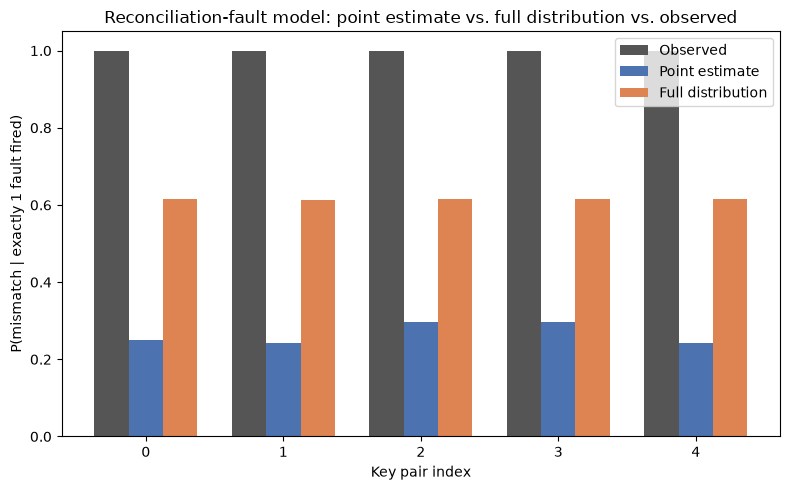

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(df_point))
width = 0.25

ax.bar(x - width, df_point["observed_mismatch_rate"], width, label="Observed", color="#555555")
ax.bar(x, df_point["predicted_mismatch_rate"], width, label="Point estimate", color="#4C72B0")
ax.bar(x + width, df_dist["predicted_mismatch_rate"], width, label="Full distribution", color="#DD8452")

ax.set_xticks(x)
ax.set_xticklabels(df_point["key_index"])
ax.set_xlabel("Key pair index")
ax.set_ylabel("P(mismatch | exactly 1 fault fired)")
ax.set_title("Reconciliation-fault model: point estimate vs. full distribution vs. observed")
ax.legend()
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "reconciliation_model_comparison_marginalized.png"), dpi=150)
plt.show()


## Reading the result

- If **both** are still rejected (p < 0.05): the point-estimate-vs-distribution question
  wasn't the real problem, and neither was the pass-ambiguity — something else is off (worth
  checking: is `keys_match` here really comparing against the *reconciled* key, or could
  residual non-fault Cascade errors, per its known even-error-cancellation property, be
  inflating the observed mismatch rate independent of anything the model can capture?).
- If the **distributional model fits but the point estimate still doesn't**: the switch was
  the fix, and you can retire `reconciliation_fault_model.py`'s point-estimate version in
  favor of this one for anything you present.
- If **both fit now** (compared to the original rejection): the real fix was #3 — the
  pass-ambiguity in how single-fault runs were being scored — and the point-estimate
  model was fine all along, just being tested against the wrong conditional probability.

Whichever it is, you now have one clean, reproducible answer instead of three dangling
threads.